#  Customer Segmentation Using Unsupervised Learning
### Mall Customers Dataset — K-Means + PCA + t-SNE

**Objective:** Cluster customers based on spending habits and propose marketing strategies tailored to each segment.

---
**Pipeline Overview:**
1. Install & Import Libraries
2. Load & Explore Dataset (EDA)
3. Feature Engineering & Preprocessing
4. K-Means Clustering (Elbow + Silhouette)
5. Cluster Analysis & Profiling
6. PCA Visualization
7. t-SNE Visualization
8. Marketing Strategies per Segment

##  Step 1: Install & Import Libraries

In [1]:
# No extra installs needed — all libraries come pre-installed in Google Colab
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11

# Cluster color palette
CLUSTER_COLORS = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']

print(' All libraries imported successfully!')

 All libraries imported successfully!


##  Step 2: Load the Dataset
> Run the cell below — a file picker will appear. Upload `Mall_Customers.csv`

In [2]:
from google.colab import files
uploaded = files.upload()   # Upload Mall_Customers.csv here

Saving Mall_Customers.csv to Mall_Customers (1).csv


In [3]:
df = pd.read_csv('Mall_Customers.csv')

# Rename columns for convenience
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

print(f' Dataset Shape : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\n Columns       : {list(df.columns)}')
df.head(10)

 Dataset Shape : 200 rows × 5 columns

 Columns       : ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


##  Step 3: Exploratory Data Analysis (EDA)

In [4]:
print('='*55)
print('  BASIC INFO')
print('='*55)
df.info()
print('\n')
print('='*55)
print('  STATISTICAL SUMMARY')
print('='*55)
df.describe().round(2)

  BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      200 non-null    int64 
 1   Gender          200 non-null    object
 2   Age             200 non-null    int64 
 3   Annual_Income   200 non-null    int64 
 4   Spending_Score  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


  STATISTICAL SUMMARY


,CustomerID,Age,Annual_Income,Spending_Score
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


In [6]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else ' No missing values!')

print('\n=== Gender Distribution ===')
print(df['Gender'].value_counts())
print(f'\nGender ratio: {df["Gender"].value_counts()["Female"]} Female / {df["Gender"].value_counts()["Male"]} Male')

=== Missing Values ===
 No missing values!

=== Gender Distribution ===
Gender
Female    112
Male       88
Name: count, dtype: int64

Gender ratio: 112 Female / 88 Male


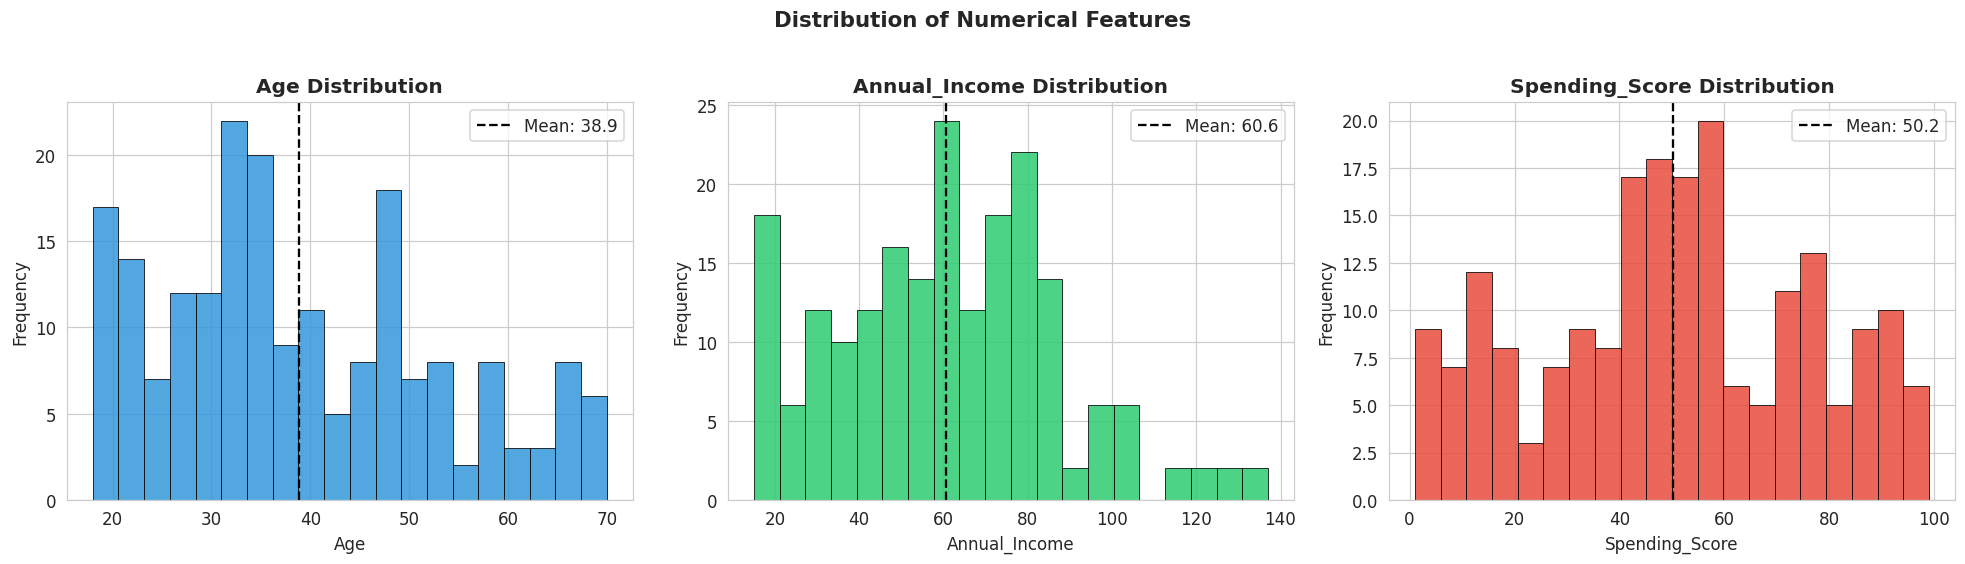

In [7]:
# ── Distribution plots for all numerical features ────────────────────────────
num_cols = ['Age', 'Annual_Income', 'Spending_Score']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#3498db', '#2ecc71', '#e74c3c']
for i, (col, color) in enumerate(zip(num_cols, colors)):
    axes[i].hist(df[col], bins=20, color=color, edgecolor='black',
                 linewidth=0.6, alpha=0.85)
    axes[i].axvline(df[col].mean(), color='black', linestyle='--',
                    linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Distribution of Numerical Features', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

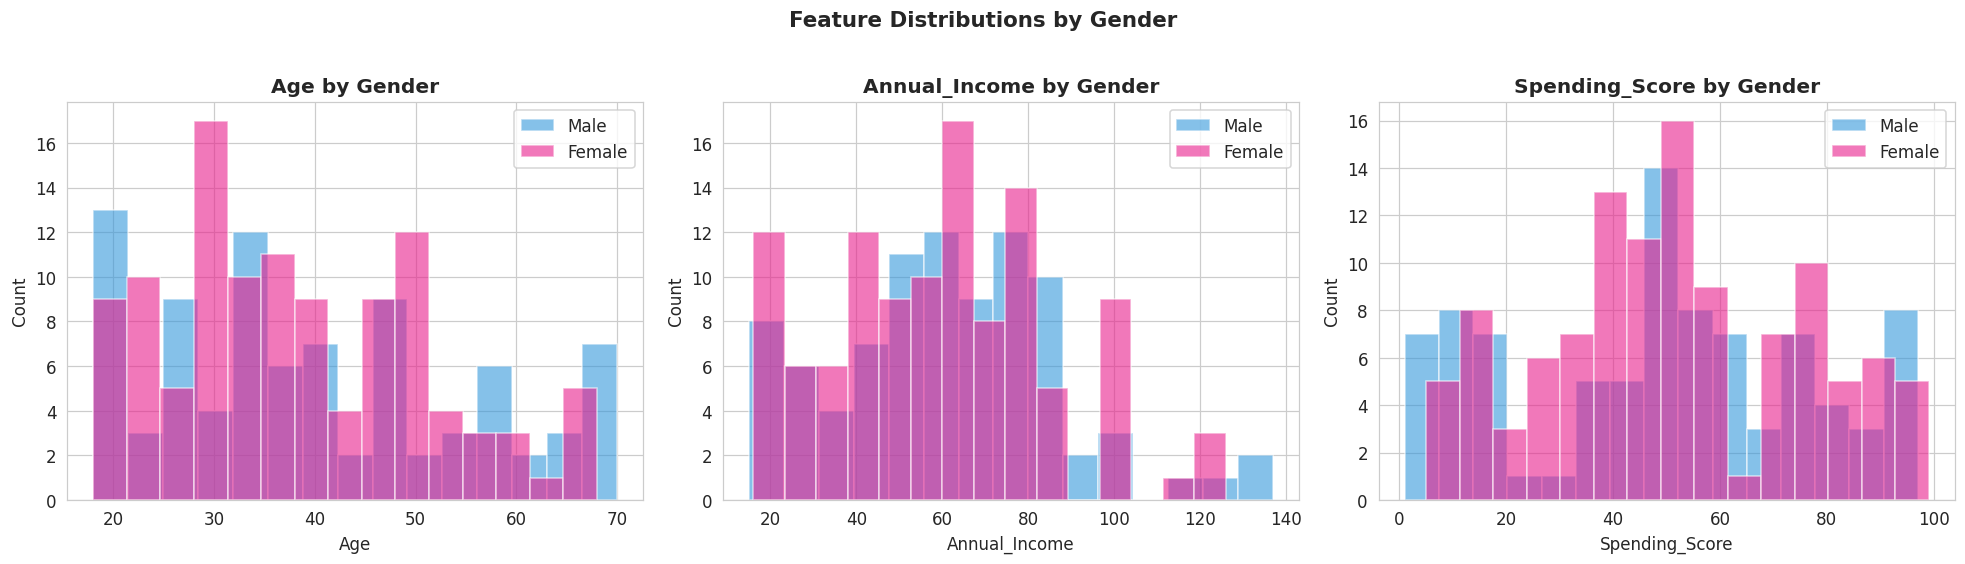

In [8]:
# ── Gender-wise comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    for gender, color in zip(['Male', 'Female'], ['#3498db', '#e91e8c']):
        axes[i].hist(df[df['Gender']==gender][col], bins=15,
                     alpha=0.6, color=color, label=gender, edgecolor='white')
    axes[i].set_title(f'{col} by Gender', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Feature Distributions by Gender', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

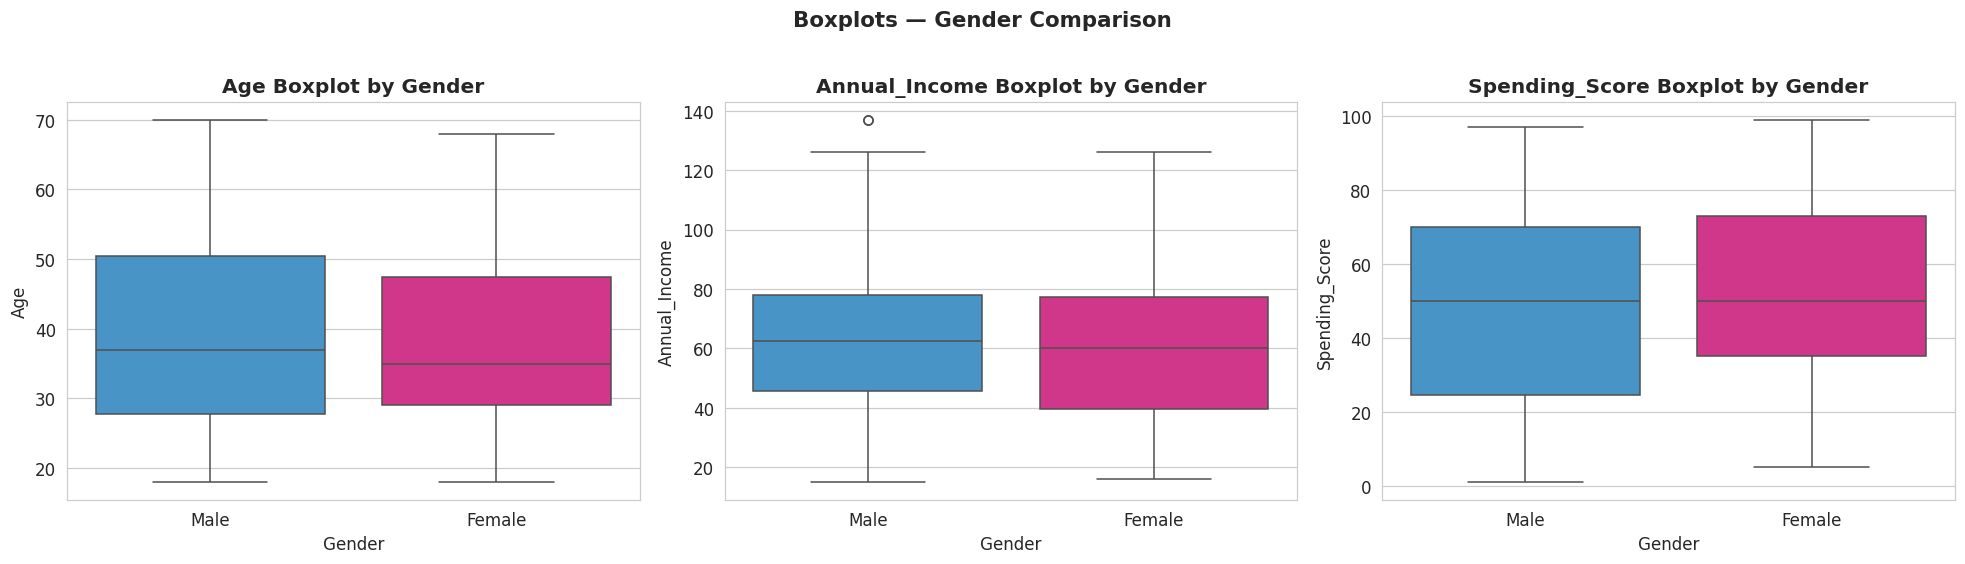

In [9]:
# ── Boxplots by Gender ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Gender', y=col, ax=axes[i],
                palette={'Male': '#3498db', 'Female': '#e91e8c'})
    axes[i].set_title(f'{col} Boxplot by Gender', fontweight='bold')

plt.suptitle('Boxplots — Gender Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

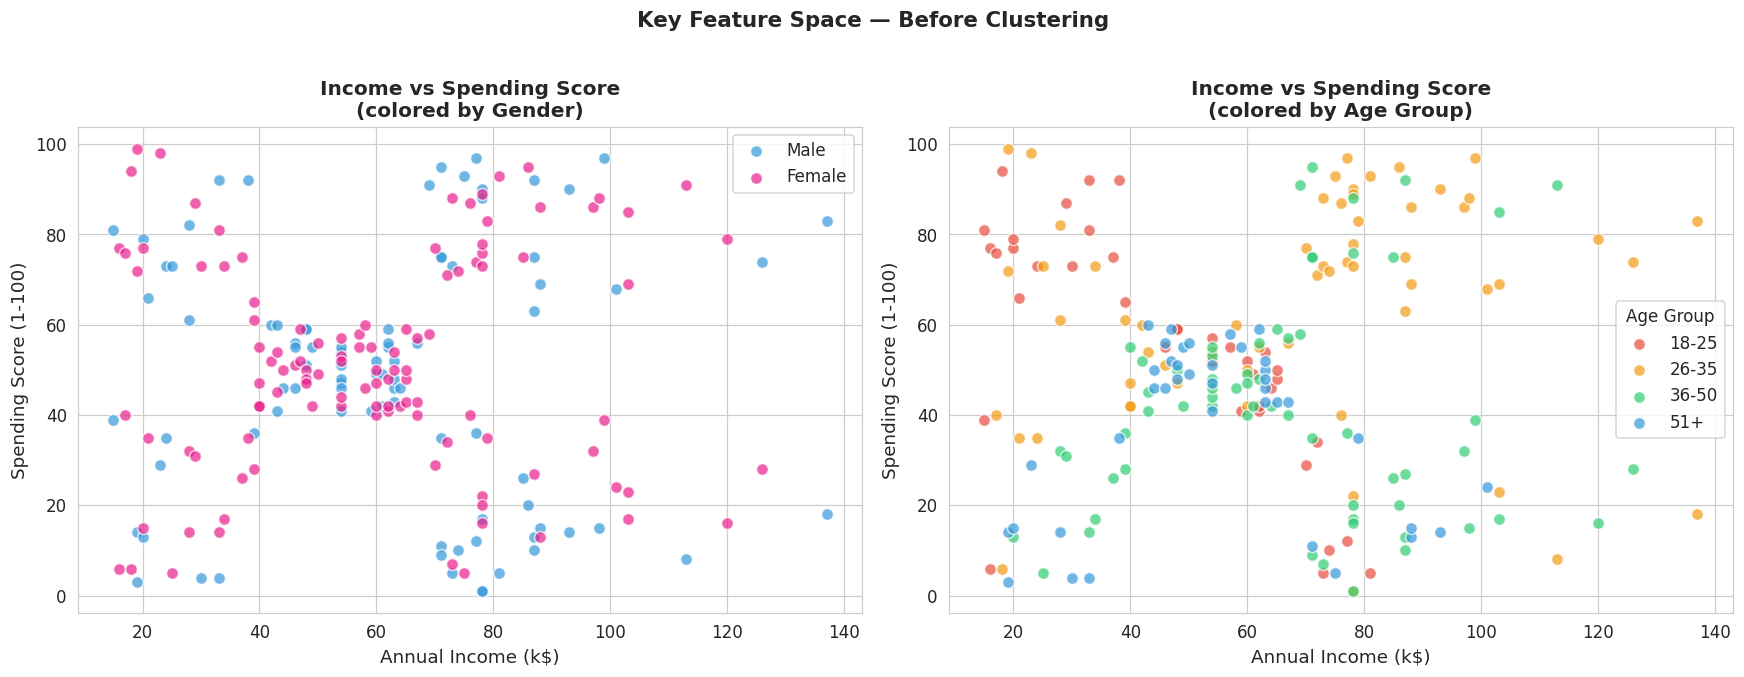

In [10]:
# ── Key scatter: Annual Income vs Spending Score (the main clustering space) ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colored by Gender
gender_colors = {'Male': '#3498db', 'Female': '#e91e8c'}
for gender, color in gender_colors.items():
    mask = df['Gender'] == gender
    axes[0].scatter(df[mask]['Annual_Income'], df[mask]['Spending_Score'],
                    c=color, label=gender, alpha=0.7, s=60, edgecolors='white')
axes[0].set_xlabel('Annual Income (k$)', fontsize=12)
axes[0].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[0].set_title('Income vs Spending Score\n(colored by Gender)',
                   fontweight='bold')
axes[0].legend()

# Colored by Age groups
df['Age_Group'] = pd.cut(df['Age'], bins=[0,25,35,50,100],
                          labels=['18-25','26-35','36-50','51+'])
age_palette = {'18-25':'#e74c3c','26-35':'#f39c12','36-50':'#2ecc71','51+':'#3498db'}
for grp, color in age_palette.items():
    mask = df['Age_Group'] == grp
    axes[1].scatter(df[mask]['Annual_Income'], df[mask]['Spending_Score'],
                    c=color, label=grp, alpha=0.7, s=60, edgecolors='white')
axes[1].set_xlabel('Annual Income (k$)', fontsize=12)
axes[1].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[1].set_title('Income vs Spending Score\n(colored by Age Group)',
                   fontweight='bold')
axes[1].legend(title='Age Group')

plt.suptitle('Key Feature Space — Before Clustering', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

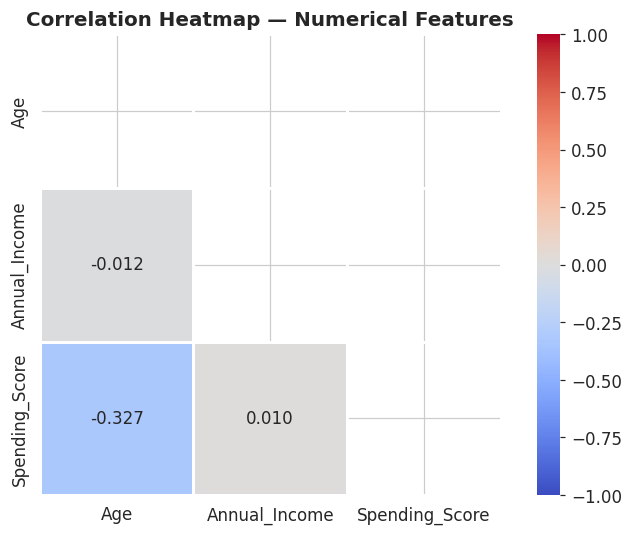

In [11]:
# ── Correlation heatmap ──────────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
corr = df[['Age','Annual_Income','Spending_Score']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            mask=mask, linewidths=0.8, square=True, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numerical Features',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

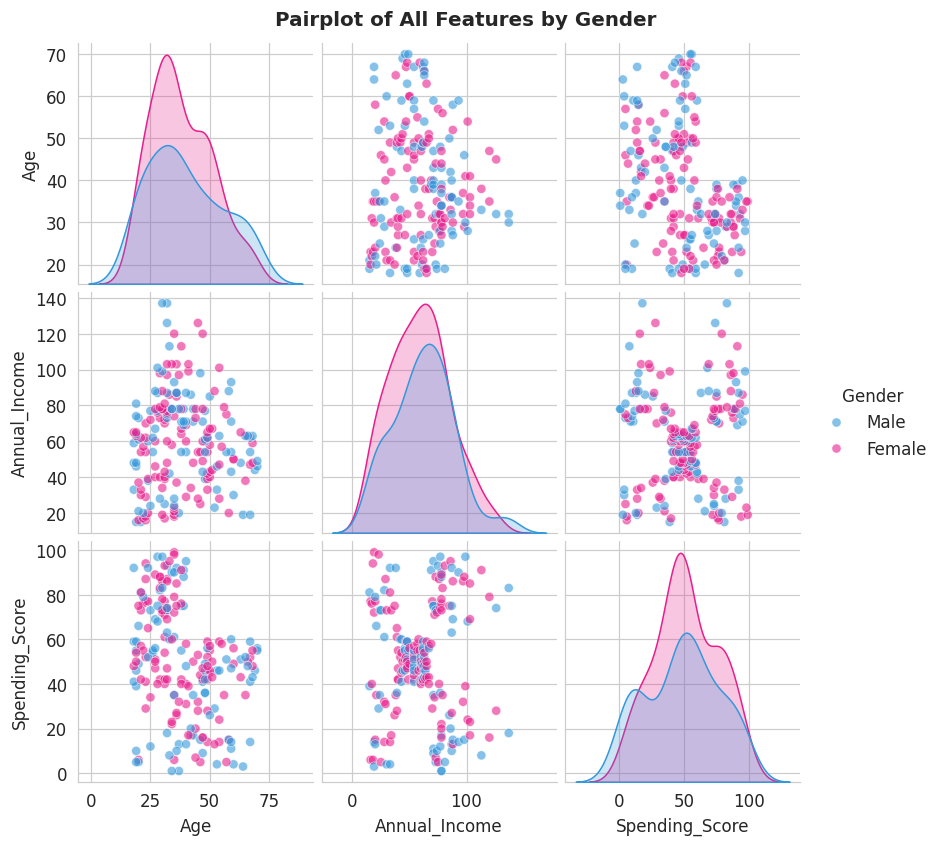

In [12]:
# ── Pairplot ─────────────────────────────────────────────────────────────────
pair_df = df[['Age','Annual_Income','Spending_Score','Gender']]
sns.pairplot(pair_df, hue='Gender',
             palette={'Male':'#3498db','Female':'#e91e8c'},
             diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle('Pairplot of All Features by Gender',
             fontsize=13, fontweight='bold', y=1.02)
plt.show()

##  Step 4: Feature Preprocessing
We use **Annual Income** and **Spending Score** as primary clustering features (the most business-relevant), then extend to all 3 numerical features.

In [14]:
# Encode Gender
le = LabelEncoder()
df['Gender_Enc'] = le.fit_transform(df['Gender'])  # Female=0, Male=1
print(f'Gender encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# ── Feature set for clustering (3 main numerical features) ──────────────────
features = ['Age', 'Annual_Income', 'Spending_Score']
X = df[features].copy()

# StandardScaler — brings all features to same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print(f'\n Features selected   : {features}')
print(f' Shape after scaling : {X_scaled.shape}')
print(f'\nScaled feature stats (mean≈0, std≈1):')
print(X_scaled_df.describe().round(3))

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}

 Features selected   : ['Age', 'Annual_Income', 'Spending_Score']
 Shape after scaling : (200, 3)

Scaled feature stats (mean≈0, std≈1):
           Age  Annual_Income  Spending_Score
count  200.000        200.000         200.000
mean    -0.000         -0.000          -0.000
std      1.003          1.003           1.003
min     -1.496         -1.739          -1.910
25%     -0.725         -0.728          -0.600
50%     -0.205          0.036          -0.008
75%      0.728          0.666           0.885
max      2.236          2.918           1.894


##  Step 5: Find Optimal K — Elbow Method + Silhouette Score

In [15]:
# ── Compute Inertia and Silhouette for K = 2 to 10 ──────────────────────────
K_range    = range(2, 11)
inertias   = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))
    print(f'  K={k}  →  Inertia: {km.inertia_:>8.2f}  |  Silhouette: {silhouette_score(X_scaled, km.labels_):.4f}')

print('\n Done!')

  K=2  →  Inertia:   389.39  |  Silhouette: 0.3355
  K=3  →  Inertia:   295.21  |  Silhouette: 0.3578
  K=4  →  Inertia:   205.23  |  Silhouette: 0.4040
  K=5  →  Inertia:   168.25  |  Silhouette: 0.4166
  K=6  →  Inertia:   133.87  |  Silhouette: 0.4284
  K=7  →  Inertia:   117.01  |  Silhouette: 0.4172
  K=8  →  Inertia:   103.87  |  Silhouette: 0.4082
  K=9  →  Inertia:    93.09  |  Silhouette: 0.4177
  K=10  →  Inertia:    82.39  |  Silhouette: 0.4066

 Done!


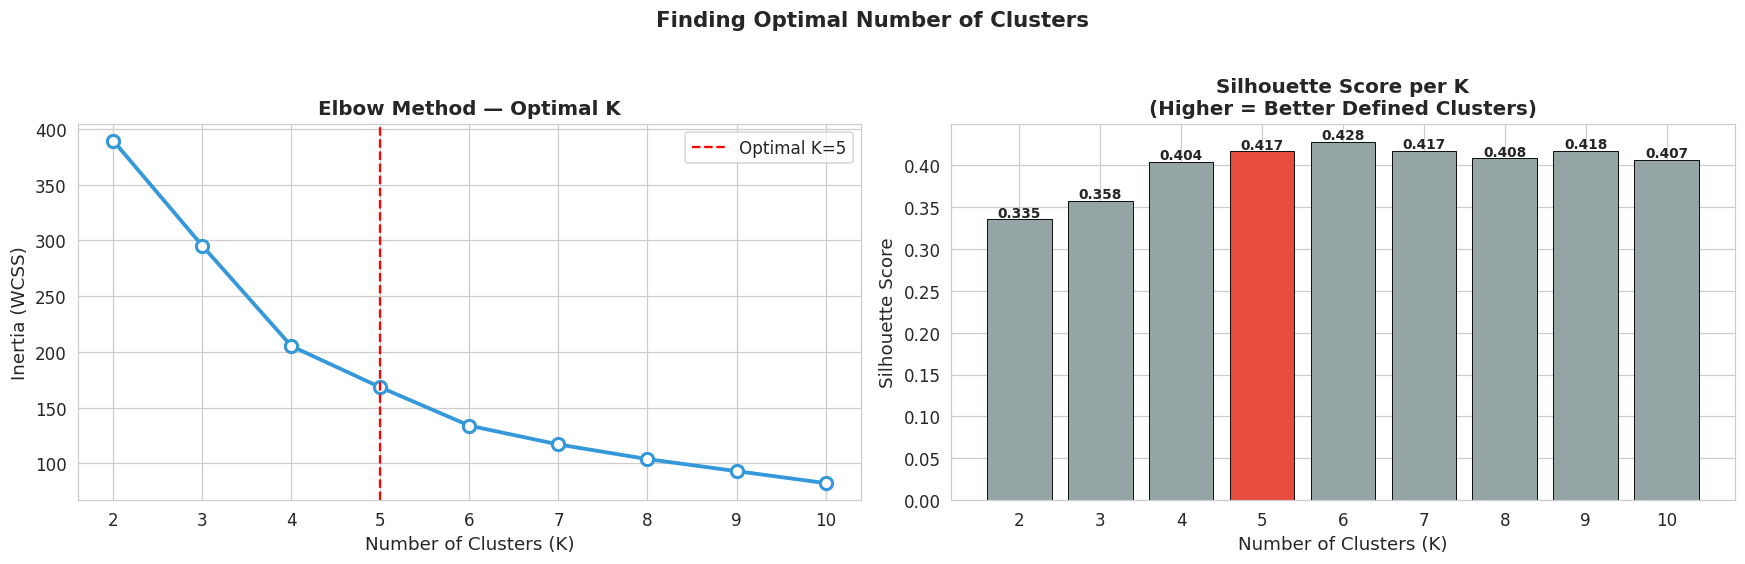


 Best K by Silhouette : K = 6  (score = 0.4284)
 Best K by Elbow      : K = 5  (visual inspection)

→ We will use K = 5 (best matches business segments)


In [16]:
# ── Plot Elbow Curve + Silhouette Scores side by side ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow
axes[0].plot(list(K_range), inertias, 'o-', color='#3498db',
             linewidth=2.5, markersize=8, markerfacecolor='white',
             markeredgewidth=2)
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=1.5,
                label='Optimal K=5')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method — Optimal K', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_xticks(list(K_range))

# Silhouette
bar_colors = ['#e74c3c' if k==5 else '#95a5a6' for k in K_range]
bars = axes[1].bar(list(K_range), sil_scores, color=bar_colors,
                   edgecolor='black', linewidth=0.6)
for bar, score in zip(bars, sil_scores):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{score:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score per K\n(Higher = Better Defined Clusters)',
                   fontsize=13, fontweight='bold')
axes[1].set_xticks(list(K_range))

plt.suptitle('Finding Optimal Number of Clusters',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_k = list(K_range)[sil_scores.index(max(sil_scores))]
print(f'\n Best K by Silhouette : K = {best_k}  (score = {max(sil_scores):.4f})')
print(f' Best K by Elbow      : K = 5  (visual inspection)')
print(f'\n→ We will use K = 5 (best matches business segments)')

##  Step 6: Apply K-Means Clustering (K=5)

In [17]:
# ── Final K-Means with K=5 ───────────────────────────────────────────────────
K_FINAL = 5
kmeans = KMeans(n_clusters=K_FINAL, init='k-means++', n_init=20,
                max_iter=500, random_state=42)
kmeans.fit(X_scaled)

df['Cluster'] = kmeans.labels_

sil = silhouette_score(X_scaled, kmeans.labels_)
print(f'   K-Means fitted!')
print(f'   K              : {K_FINAL}')
print(f'   Inertia        : {kmeans.inertia_:.2f}')
print(f'   Silhouette     : {sil:.4f}')
print(f'\nCluster sizes:')
print(df['Cluster'].value_counts().sort_index())

   K-Means fitted!
   K              : 5
   Inertia        : 168.25
   Silhouette     : 0.4166

Cluster sizes:
Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64


##  Step 7: Cluster Analysis & Profiling

In [18]:
# ── Cluster-wise statistics ──────────────────────────────────────────────────
profile = df.groupby('Cluster').agg(
    Count        = ('CustomerID','count'),
    Avg_Age      = ('Age','mean'),
    Avg_Income   = ('Annual_Income','mean'),
    Avg_Spending = ('Spending_Score','mean'),
    Pct_Female   = ('Gender', lambda x: (x=='Female').mean()*100)
).round(2)

# Assign descriptive segment names based on Income + Spending pattern
segment_names = {
    0: ' High Income, Low Spender',
    1: ' High Income, High Spender',
    2: ' Mid Income, Mid Spender',
    3: '  Low Income, High Spender',
    4: ' Low Income, Low Spender'
}

# NOTE: Segment names may need swapping based on your actual cluster output.
# Check profile table below and re-assign if needed.
profile['Segment_Name'] = profile.index.map(segment_names)

print('='*80)
print('  CLUSTER PROFILE SUMMARY')
print('='*80)
print(profile.to_string())
print('='*80)

  CLUSTER PROFILE SUMMARY
         Count  Avg_Age  Avg_Income  Avg_Spending  Pct_Female                Segment_Name
Cluster                                                                                  
0           20    46.25       26.75         18.35       60.00    High Income, Low Spender
1           54    25.19       41.09         62.24       59.26   High Income, High Spender
2           40    32.88       86.10         81.53       55.00     Mid Income, Mid Spender
3           39    39.87       86.10         19.36       48.72    Low Income, High Spender
4           47    55.64       54.38         48.85       57.45     Low Income, Low Spender


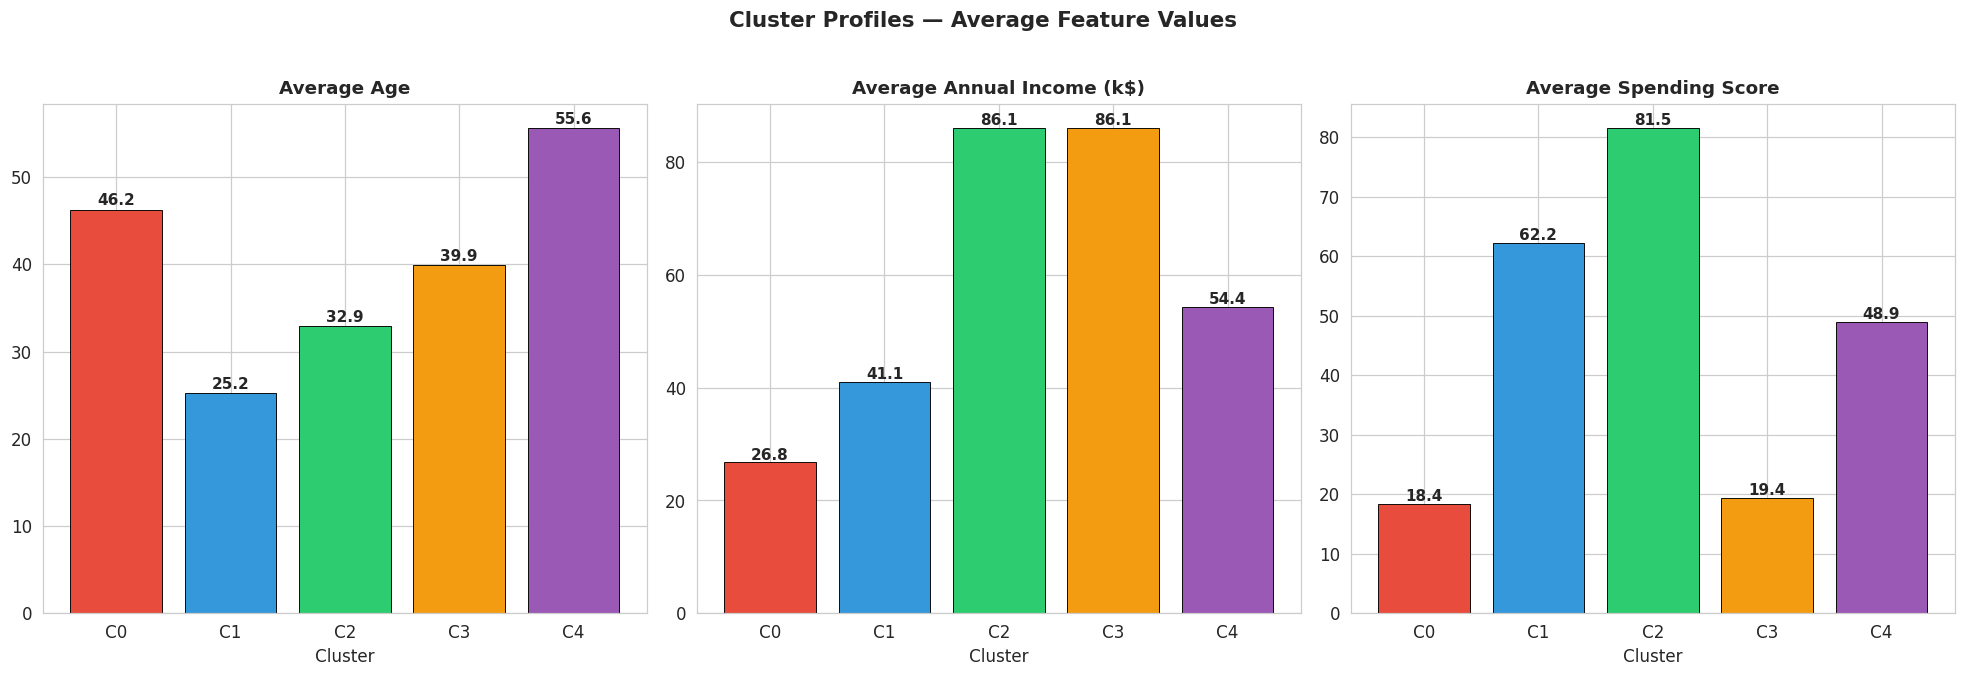

In [19]:
# ── Cluster profile bar charts ───────────────────────────────────────────────
metrics  = ['Avg_Age', 'Avg_Income', 'Avg_Spending']
titles   = ['Average Age', 'Average Annual Income (k$)', 'Average Spending Score']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (metric, title) in enumerate(zip(metrics, titles)):
    bars = axes[i].bar(profile.index, profile[metric],
                       color=CLUSTER_COLORS, edgecolor='black', linewidth=0.6)
    for bar in bars:
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f'{bar.get_height():.1f}', ha='center',
                     fontsize=10, fontweight='bold')
    axes[i].set_title(title, fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Cluster')
    axes[i].set_xticks(range(K_FINAL))
    axes[i].set_xticklabels([f'C{k}' for k in range(K_FINAL)])

plt.suptitle('Cluster Profiles — Average Feature Values',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

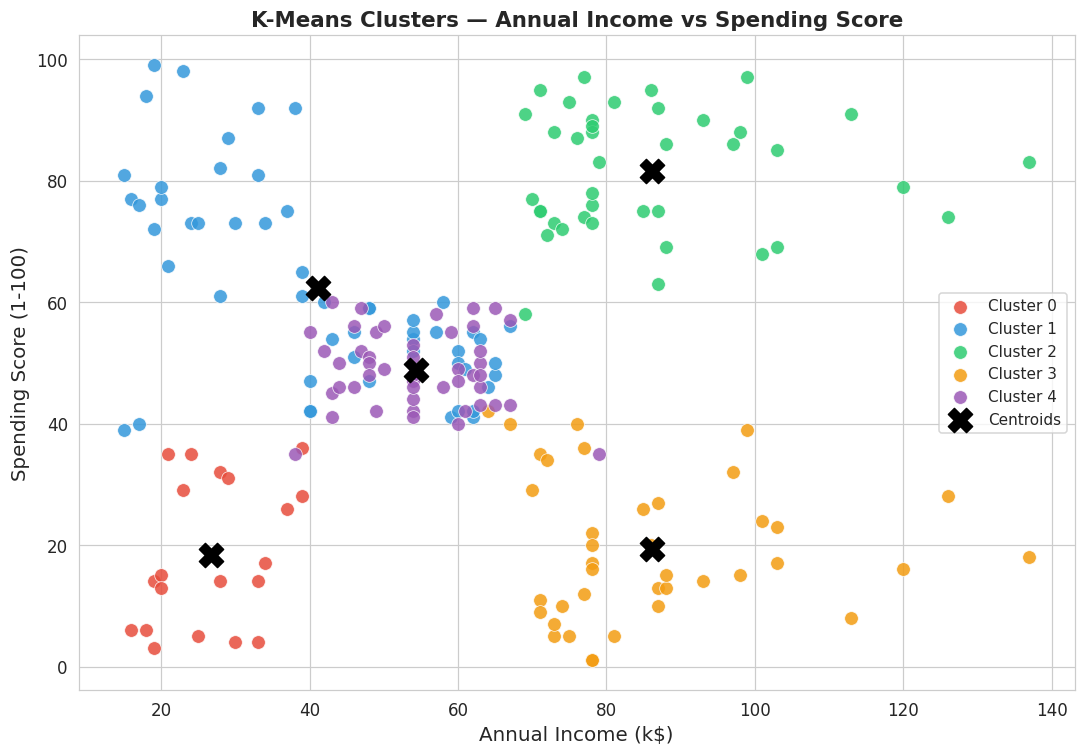

In [20]:
# ── 2D scatter: Income vs Spending (the clearest cluster view) ───────────────
fig, ax = plt.subplots(figsize=(10, 7))

for cluster in range(K_FINAL):
    mask = df['Cluster'] == cluster
    ax.scatter(df[mask]['Annual_Income'], df[mask]['Spending_Score'],
               c=CLUSTER_COLORS[cluster], s=80, alpha=0.85,
               edgecolors='white', linewidth=0.5,
               label=f'Cluster {cluster}')

# Plot cluster centroids (inverse transform back to original scale)
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(centers_orig[:, 1], centers_orig[:, 2],
           c='black', s=250, marker='X', zorder=5, label='Centroids')

ax.set_xlabel('Annual Income (k$)', fontsize=13)
ax.set_ylabel('Spending Score (1-100)', fontsize=13)
ax.set_title('K-Means Clusters — Annual Income vs Spending Score',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

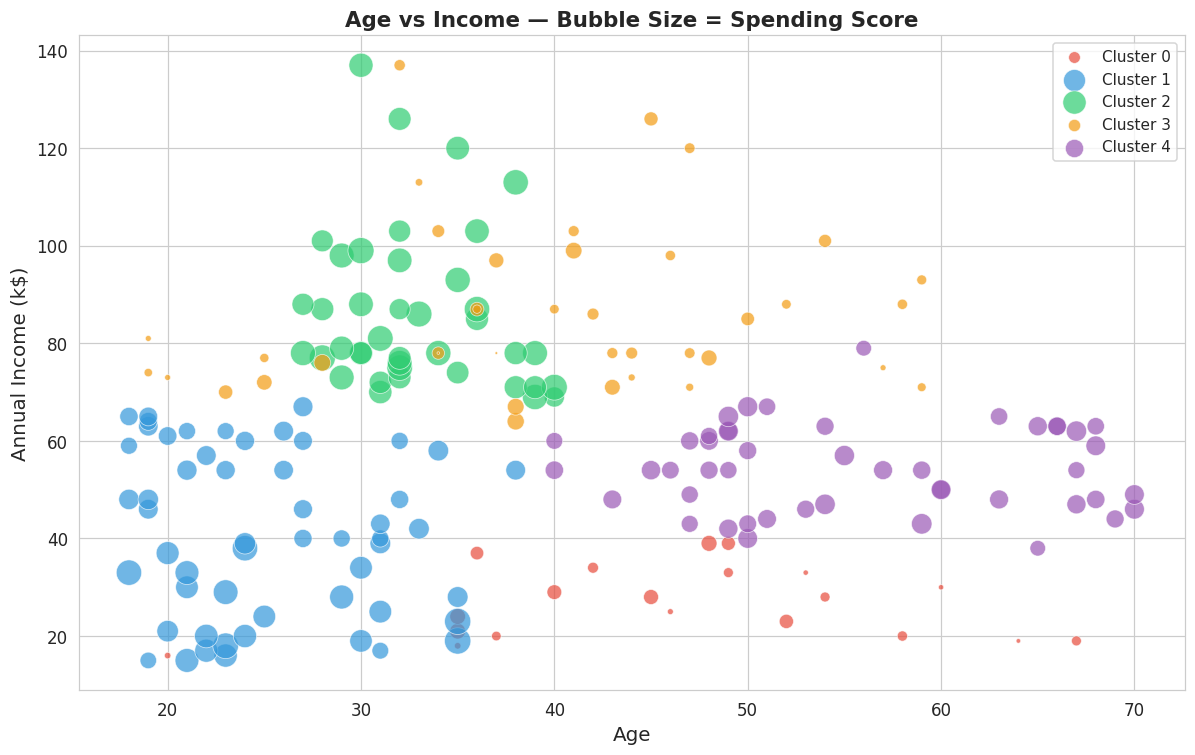

In [21]:
# ── 3D-style: Age vs Income vs Spending, bubble size = Spending Score ─────────
fig, ax = plt.subplots(figsize=(11, 7))

for cluster in range(K_FINAL):
    mask = df['Cluster'] == cluster
    ax.scatter(df[mask]['Age'], df[mask]['Annual_Income'],
               s=df[mask]['Spending_Score']*3,
               c=CLUSTER_COLORS[cluster], alpha=0.7,
               edgecolors='white', linewidth=0.5,
               label=f'Cluster {cluster}')

ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('Annual Income (k$)', fontsize=13)
ax.set_title('Age vs Income — Bubble Size = Spending Score',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

##  Step 8: PCA Visualization
**PCA (Principal Component Analysis)** reduces 3 features → 2 components so we can visualize clusters in 2D.

In [22]:
# ── Apply PCA ────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f' PCA applied!')
print(f'   Original dimensions : {X_scaled.shape[1]}')
print(f'   Reduced dimensions  : {X_pca.shape[1]}')
print(f'\n   Explained variance  :')
for i, ev in enumerate(pca.explained_variance_ratio_):
    print(f'   PC{i+1}: {ev*100:.2f}%')
print(f'   Total : {sum(pca.explained_variance_ratio_)*100:.2f}%')

 PCA applied!
   Original dimensions : 3
   Reduced dimensions  : 2

   Explained variance  :
   PC1: 44.27%
   PC2: 33.31%
   Total : 77.57%


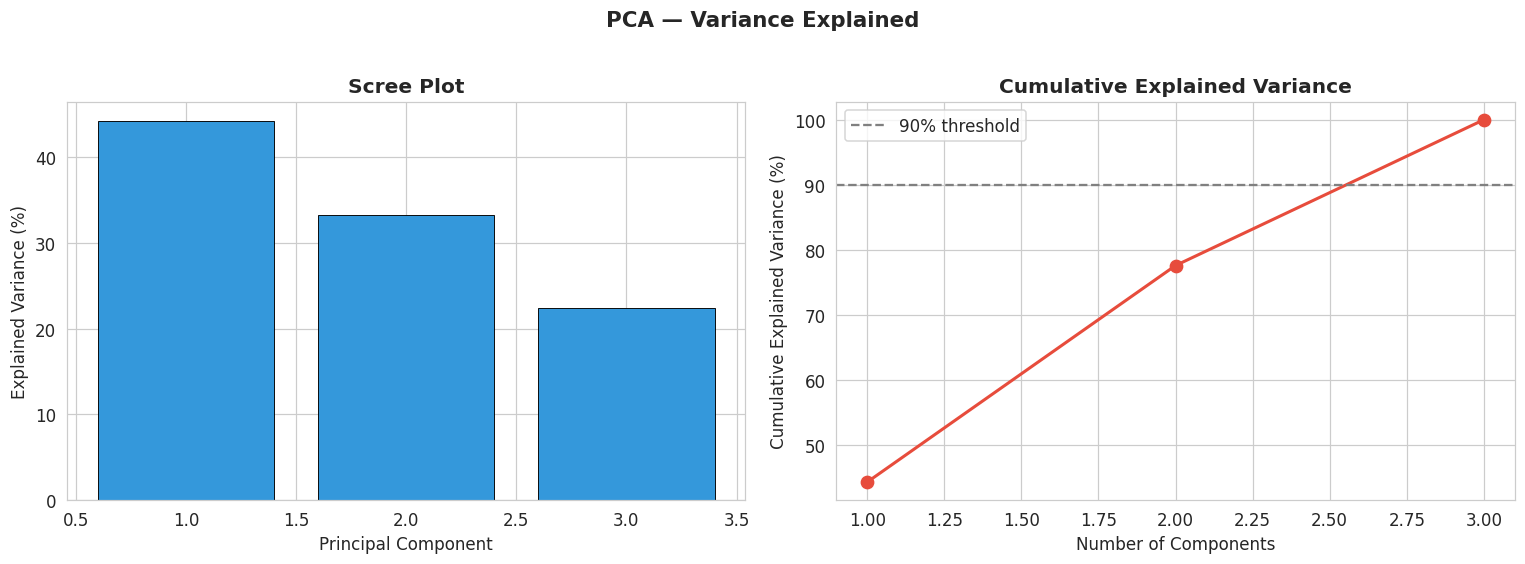

In [23]:
# ── PCA Scree Plot ───────────────────────────────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_*100,
            color='#3498db', edgecolor='black', linewidth=0.6)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot', fontweight='bold')

# Cumulative
cumulative = np.cumsum(pca_full.explained_variance_ratio_*100)
axes[1].plot(range(1, len(cumulative)+1), cumulative, 'o-',
             color='#e74c3c', linewidth=2, markersize=8)
axes[1].axhline(y=90, color='gray', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()

plt.suptitle('PCA — Variance Explained', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

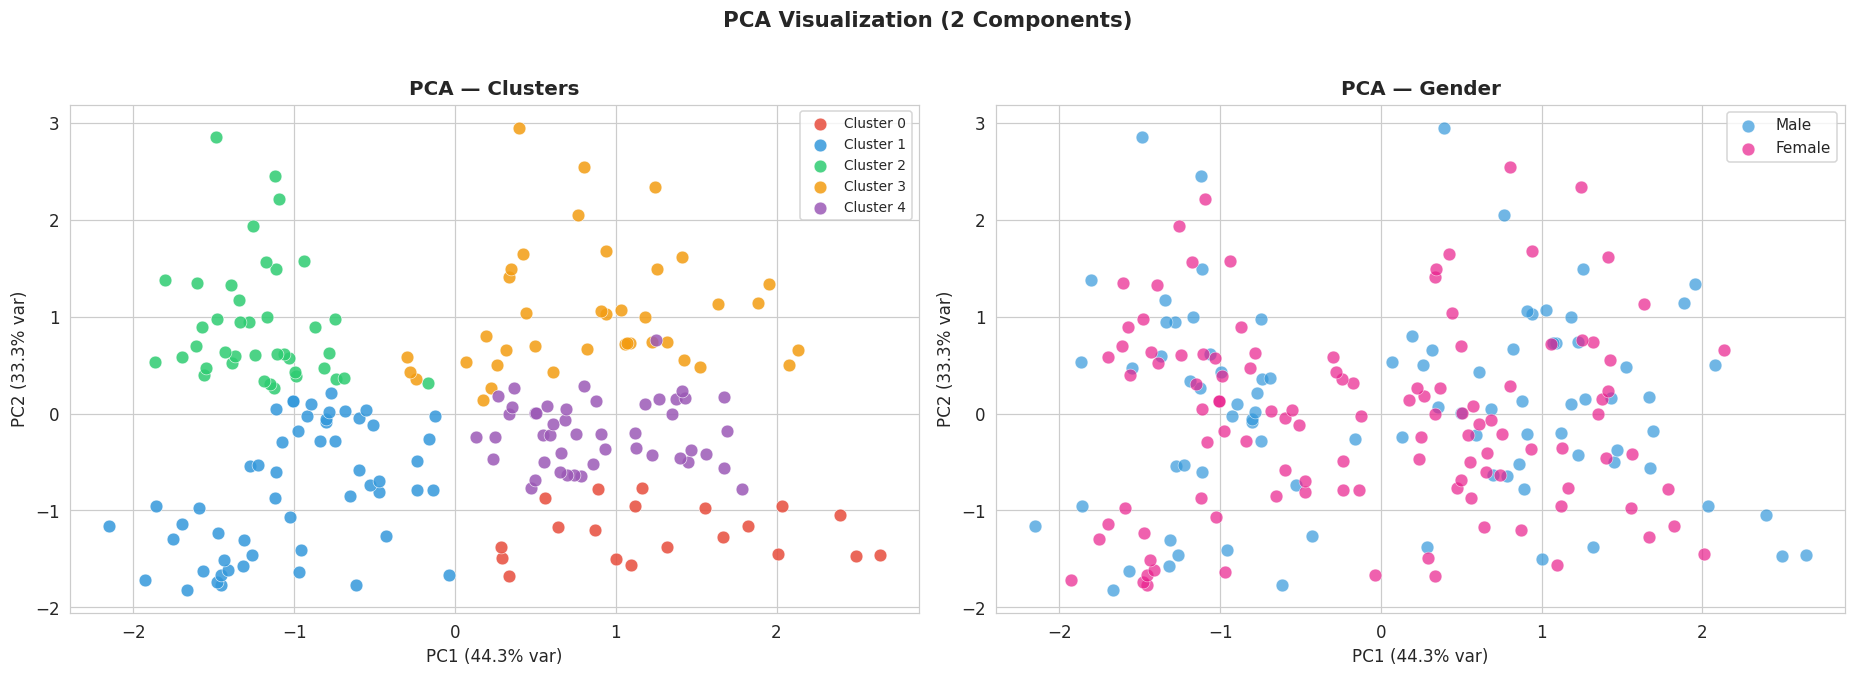

In [24]:
# ── PCA Cluster Visualization ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Colored by Cluster
for cluster in range(K_FINAL):
    mask = df['Cluster'] == cluster
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=CLUSTER_COLORS[cluster], s=70, alpha=0.85,
                    edgecolors='white', linewidth=0.4,
                    label=f'Cluster {cluster}')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=11)
axes[0].set_title('PCA — Clusters', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)

# Colored by Gender
for gender, color in {'Male':'#3498db','Female':'#e91e8c'}.items():
    mask = df['Gender'] == gender
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, s=70, alpha=0.7,
                    edgecolors='white', linewidth=0.4, label=gender)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=11)
axes[1].set_title('PCA — Gender', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('PCA Visualization (2 Components)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

PCA Feature Loadings (how much each feature contributes to each PC):
                   PC1     PC2
Age             0.7064  0.0301
Annual_Income  -0.0480  0.9988
Spending_Score -0.7062 -0.0378


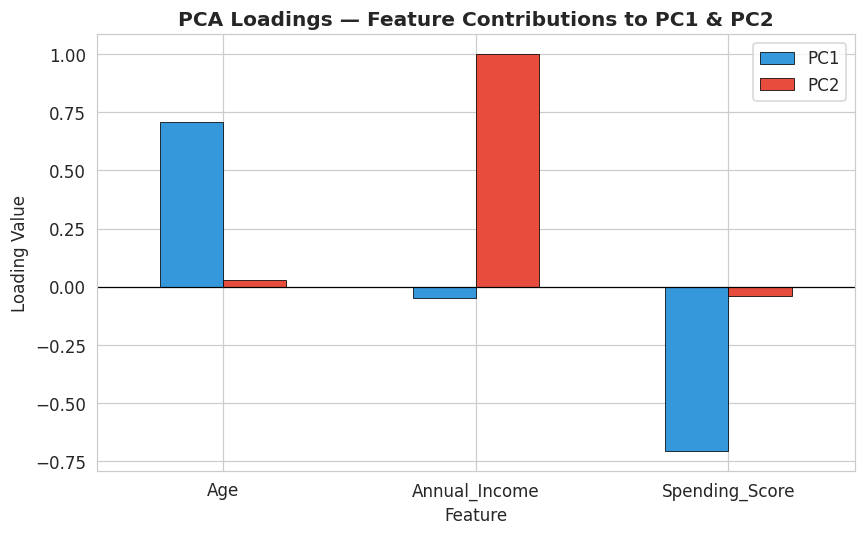

In [25]:
# ── PCA Loadings (Feature Contributions) ────────────────────────────────────
loadings = pd.DataFrame(pca.components_.T,
                         index=features,
                         columns=['PC1','PC2']).round(4)

print('PCA Feature Loadings (how much each feature contributes to each PC):')
print(loadings)

fig, ax = plt.subplots(figsize=(8, 5))
loadings.plot(kind='bar', ax=ax, color=['#3498db','#e74c3c'],
              edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('PCA Loadings — Feature Contributions to PC1 & PC2',
             fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Loading Value')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

##  Step 9: t-SNE Visualization
**t-SNE** is a non-linear technique that preserves local structure — often shows cleaner cluster separation than PCA.

In [26]:
# ── Apply t-SNE ──────────────────────────────────────────────────────────────
print('Running t-SNE (may take ~20 seconds)...')
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000,
            random_state=42, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_scaled)

print(f'    t-SNE complete!')
print(f'   Input shape  : {X_scaled.shape}')
print(f'   Output shape : {X_tsne.shape}')

Running t-SNE (may take ~20 seconds)...
    t-SNE complete!
   Input shape  : (200, 3)
   Output shape : (200, 2)


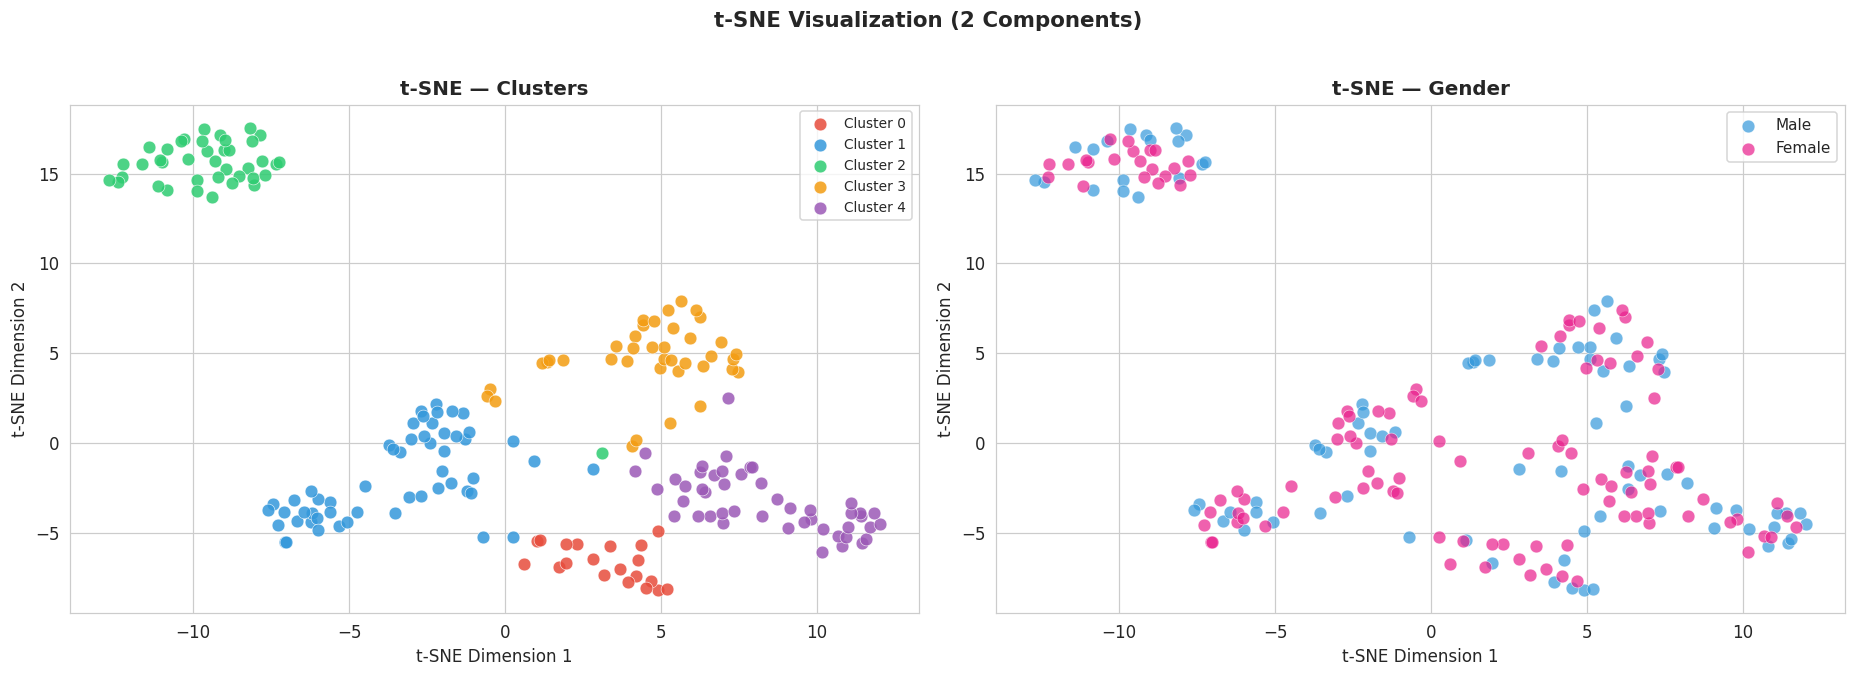

In [27]:
# ── t-SNE Cluster Visualization ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Colored by Cluster
for cluster in range(K_FINAL):
    mask = df['Cluster'] == cluster
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=CLUSTER_COLORS[cluster], s=70, alpha=0.85,
                    edgecolors='white', linewidth=0.4,
                    label=f'Cluster {cluster}')
axes[0].set_xlabel('t-SNE Dimension 1', fontsize=11)
axes[0].set_ylabel('t-SNE Dimension 2', fontsize=11)
axes[0].set_title('t-SNE — Clusters', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)

# Colored by Gender
for gender, color in {'Male':'#3498db','Female':'#e91e8c'}.items():
    mask = df['Gender'] == gender
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=color, s=70, alpha=0.7,
                    edgecolors='white', linewidth=0.4, label=gender)
axes[1].set_xlabel('t-SNE Dimension 1', fontsize=11)
axes[1].set_ylabel('t-SNE Dimension 2', fontsize=11)
axes[1].set_title('t-SNE — Gender', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('t-SNE Visualization (2 Components)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

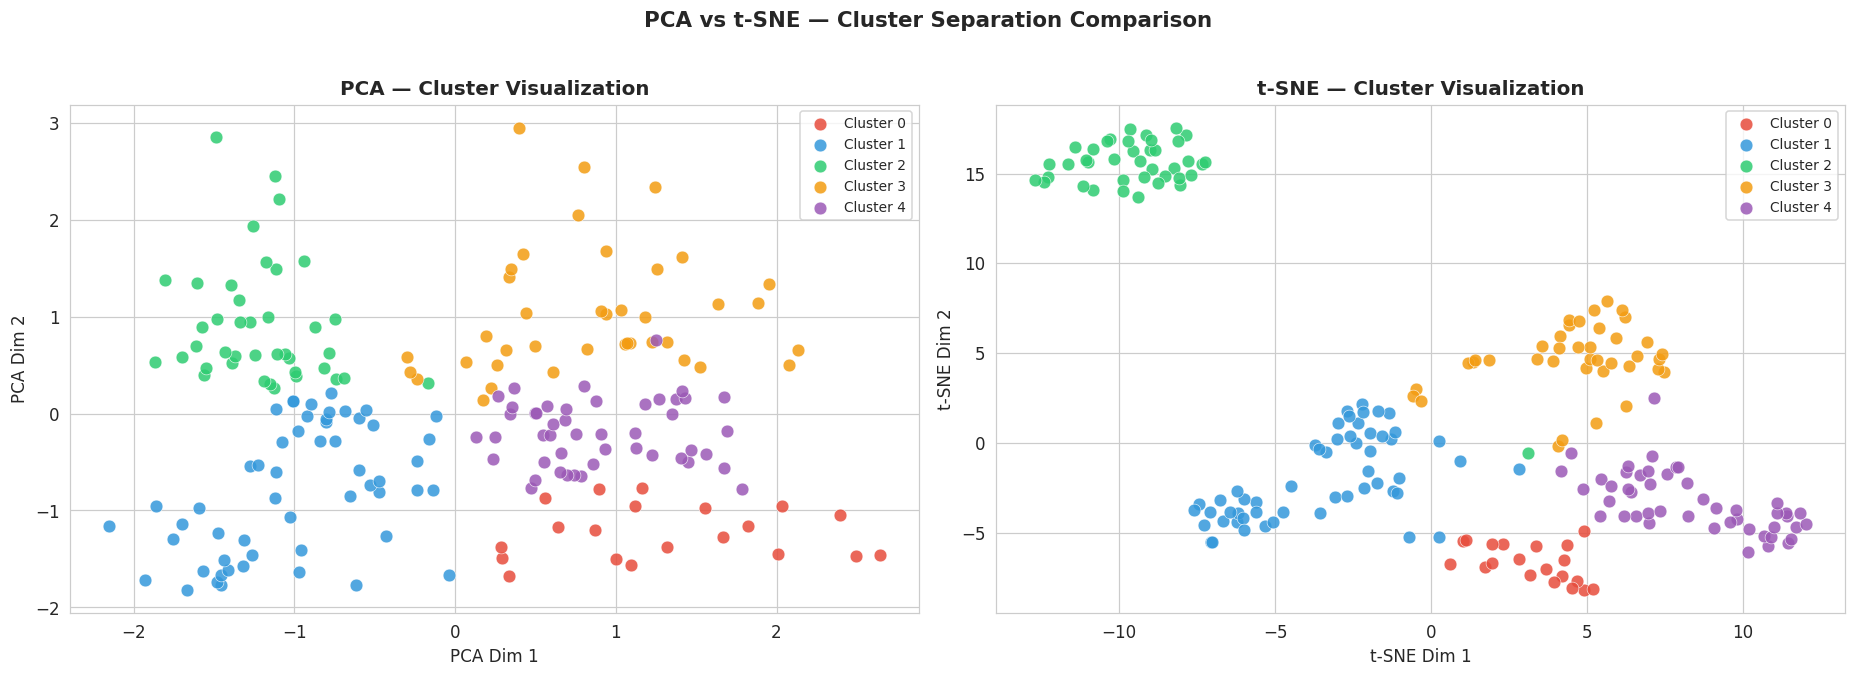

In [28]:
# ── PCA vs t-SNE side by side comparison ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

for ax, X_reduced, method in zip(axes,
                                  [X_pca, X_tsne],
                                  ['PCA', 't-SNE']):
    for cluster in range(K_FINAL):
        mask = df['Cluster'] == cluster
        ax.scatter(X_reduced[mask, 0], X_reduced[mask, 1],
                   c=CLUSTER_COLORS[cluster], s=70, alpha=0.85,
                   edgecolors='white', linewidth=0.4,
                   label=f'Cluster {cluster}')
    ax.set_title(f'{method} — Cluster Visualization',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel(f'{method} Dim 1')
    ax.set_ylabel(f'{method} Dim 2')
    ax.legend(fontsize=9)

plt.suptitle('PCA vs t-SNE — Cluster Separation Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##  Step 10: Marketing Strategies per Segment
Based on cluster profiles, we assign segment names and propose targeted marketing strategies.

In [29]:
# ── Auto-assign segment names based on actual cluster stats ──────────────────
# Sort clusters by Annual Income and Spending Score for consistent labeling
cluster_stats = df.groupby('Cluster')[['Annual_Income','Spending_Score']].mean()

print('Cluster Stats (to verify segment naming):')
print(cluster_stats.round(2))
print()

# ── Marketing Strategies Dictionary ─────────────────────────────────────────
strategies = {
    0: {
        'name'    : ' Cautious High Earners',
        'profile' : 'High income but low spending — they earn well but spend conservatively.',
        'strategy': [
            '→ Offer exclusive premium loyalty programs to incentivize spending',
            '→ Promote luxury or investment products (wealth management, premium cards)',
            '→ Send personalized "value for money" deals to trigger purchases',
            '→ Focus on quality and exclusivity messaging, not discounts'
        ]
    },
    1: {
        'name'    : ' VIP Spenders',
        'profile' : 'High income AND high spending — the ideal, most valuable customer segment.',
        'strategy': [
            '→ Offer VIP membership, early access, and exclusive rewards',
            '→ Upsell premium and high-margin products',
            '→ Provide dedicated personal shoppers or concierge service',
            '→ Retain with surprise gifts, loyalty points, and milestone rewards'
        ]
    },
    2: {
        'name'    : ' Average Joes',
        'profile' : 'Middle income and middle spending — the largest, most common segment.',
        'strategy': [
            '→ Promote bundles and combo deals for better perceived value',
            '→ Run seasonal sales, flash deals, and limited-time offers',
            '→ Use referral programs (refer-a-friend) to grow reach',
            '→ Email campaigns with personalized product recommendations'
        ]
    },
    3: {
        'name'    : '  Impulsive Shoppers',
        'profile' : 'Low income but high spending — they love shopping despite limited budgets.',
        'strategy': [
            '→ Offer easy EMI / Buy-Now-Pay-Later (BNPL) installment options',
            '→ Push frequent discounts, flash sales, and coupon codes',
            '→ Gamify shopping with spin-to-win rewards and daily check-ins',
            '→ Promote affordable trending products and social-media-viral items'
        ]
    },
    4: {
        'name'    : ' Budget Conscious',
        'profile' : 'Low income and low spending — price-sensitive, rarely purchase.',
        'strategy': [
            '→ Target with deep discounts, clearance sales, and value packs',
            '→ Introduce a free-tier or trial membership to build engagement',
            '→ Send re-engagement campaigns ("We miss you!") with exclusive coupons',
            '→ Focus on essential, everyday low-cost products'
        ]
    }
}

# ── Print all strategies ─────────────────────────────────────────────────────
print('\n' + '='*70)
print('   MARKETING STRATEGIES PER CUSTOMER SEGMENT')
print('='*70)

for cluster_id, info in strategies.items():
    stats = cluster_stats.loc[cluster_id]
    size  = (df['Cluster'] == cluster_id).sum()
    print(f'\n┌─ Cluster {cluster_id}  |  {info["name"]}')
    print(f'│  Size          : {size} customers ({size/len(df)*100:.1f}%)')
    print(f'│  Avg Income    : ${stats["Annual_Income"]:.1f}k')
    print(f'│  Avg Spending  : {stats["Spending_Score"]:.1f}/100')
    print(f'│  Profile       : {info["profile"]}')
    print(f'│  Strategies    :')
    for strat in info['strategy']:
        print(f'│    {strat}')
    print('└' + '─'*68)

Cluster Stats (to verify segment naming):
         Annual_Income  Spending_Score
Cluster                               
0                26.75           18.35
1                41.09           62.24
2                86.10           81.53
3                86.10           19.36
4                54.38           48.85


   MARKETING STRATEGIES PER CUSTOMER SEGMENT

┌─ Cluster 0  |   Cautious High Earners
│  Size          : 20 customers (10.0%)
│  Avg Income    : $26.8k
│  Avg Spending  : 18.4/100
│  Profile       : High income but low spending — they earn well but spend conservatively.
│  Strategies    :
│    → Offer exclusive premium loyalty programs to incentivize spending
│    → Promote luxury or investment products (wealth management, premium cards)
│    → Send personalized "value for money" deals to trigger purchases
│    → Focus on quality and exclusivity messaging, not discounts
└────────────────────────────────────────────────────────────────────

┌─ Cluster 1  |   VIP Spenders
│  S

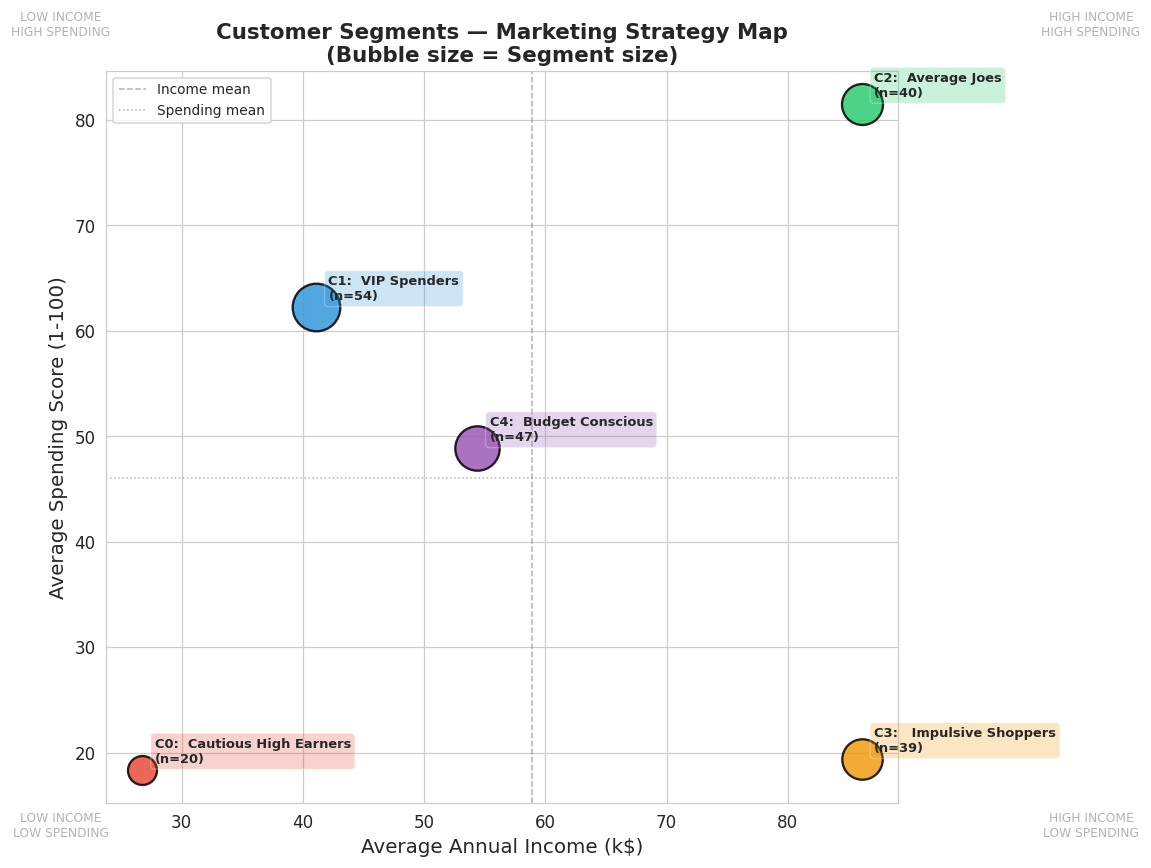

In [30]:
# ── Visual Marketing Strategy Summary ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))

# Bubble plot: Income vs Spending, bubble = cluster size
for cluster_id in range(K_FINAL):
    stats  = cluster_stats.loc[cluster_id]
    size   = (df['Cluster'] == cluster_id).sum()
    name   = strategies[cluster_id]['name']

    ax.scatter(stats['Annual_Income'], stats['Spending_Score'],
               s=size*18, c=CLUSTER_COLORS[cluster_id],
               alpha=0.85, edgecolors='black', linewidth=1.5, zorder=3)

    ax.annotate(f'C{cluster_id}: {name}\n(n={size})',
                xy=(stats['Annual_Income'], stats['Spending_Score']),
                xytext=(8, 5), textcoords='offset points',
                fontsize=8.5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor=CLUSTER_COLORS[cluster_id],
                          alpha=0.25))

# Quadrant lines
ax.axvline(x=cluster_stats['Annual_Income'].mean(), color='gray',
           linestyle='--', linewidth=1, alpha=0.6, label='Income mean')
ax.axhline(y=cluster_stats['Spending_Score'].mean(), color='gray',
           linestyle=':', linewidth=1, alpha=0.6, label='Spending mean')

# Quadrant labels
ax.text(20, 88, 'LOW INCOME\nHIGH SPENDING', fontsize=8,
        color='gray', alpha=0.6, ha='center')
ax.text(105, 88, 'HIGH INCOME\nHIGH SPENDING', fontsize=8,
        color='gray', alpha=0.6, ha='center')
ax.text(20, 12, 'LOW INCOME\nLOW SPENDING', fontsize=8,
        color='gray', alpha=0.6, ha='center')
ax.text(105, 12, 'HIGH INCOME\nLOW SPENDING', fontsize=8,
        color='gray', alpha=0.6, ha='center')

ax.set_xlabel('Average Annual Income (k$)', fontsize=13)
ax.set_ylabel('Average Spending Score (1-100)', fontsize=13)
ax.set_title('Customer Segments — Marketing Strategy Map\n(Bubble size = Segment size)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

##  Step 11: Final Summary

In [31]:
# ── Final complete summary table ─────────────────────────────────────────────
final_df = df.groupby('Cluster').agg(
    Segment_Size    = ('CustomerID','count'),
    Avg_Age         = ('Age','mean'),
    Avg_Income_k    = ('Annual_Income','mean'),
    Avg_Spending    = ('Spending_Score','mean'),
    Female_Pct      = ('Gender', lambda x: f"{(x=='Female').mean()*100:.0f}%")
).round(1)

final_df['Segment_Name'] = [strategies[i]['name'] for i in final_df.index]
final_df['Pct_of_Total'] = (final_df['Segment_Size']/len(df)*100).round(1).astype(str) + '%'

print('\n' + '='*85)
print('   FINAL CUSTOMER SEGMENTATION SUMMARY')
print('='*85)
print(final_df[['Segment_Name','Segment_Size','Pct_of_Total',
                 'Avg_Age','Avg_Income_k','Avg_Spending','Female_Pct']].to_string())
print('='*85)
print(f'\nTotal Customers  : {len(df)}')
print(f'Number of Clusters: {K_FINAL}')
print(f'Silhouette Score  : {sil:.4f}  (range: -1 to 1, higher is better)')
print(f'\n KEY INSIGHT:')
print(f'   → VIP Spenders (High Income + High Spending) are the most valuable segment')
print(f'   → Cautious High Earners have untapped potential — focus retention & upsell')
print(f'   → Impulsive Shoppers need BNPL options to sustain their spending habits')
print(f'   → Budget Conscious segment needs re-engagement with strong discount offers')


   FINAL CUSTOMER SEGMENTATION SUMMARY
                   Segment_Name  Segment_Size Pct_of_Total  Avg_Age  Avg_Income_k  Avg_Spending Female_Pct
Cluster                                                                                                   
0         Cautious High Earners            20        10.0%     46.2          26.8          18.4        60%
1                  VIP Spenders            54        27.0%     25.2          41.1          62.2        59%
2                  Average Joes            40        20.0%     32.9          86.1          81.5        55%
3            Impulsive Shoppers            39        19.5%     39.9          86.1          19.4        49%
4              Budget Conscious            47        23.5%     55.6          54.4          48.9        57%

Total Customers  : 200
Number of Clusters: 5
Silhouette Score  : 0.4166  (range: -1 to 1, higher is better)

 KEY INSIGHT:
   → VIP Spenders (High Income + High Spending) are the most valuable segment
   → Caut